<a href="https://colab.research.google.com/github/sjkim0520/Control_System/blob/main/GPR_Identification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Gaussian Process Regression (GPR) for Nonlinear System Identification
#비모수적(non-parametric)확률 모델을 사용하여 비선형 동역학
#f(x)=dx/dt를 추정하고, 예측의 불확실성(분산)을 함께 정량화한다.

#SINDy와의 차이점:
#SINDy는 명시적 방정식(해석 가능한 수식)을 도출
#GPR은 방정식 형태를 가정하지 않고, 데이터 포인트 간 유사도(커널)만으로 함수를 확률적으로 추정
#대신 예측신뢰구간(uncertainty)을 제공

#동일한 Lorenz 시스템 데이터를 사용하여 SINDy 결과와 비교할 수 있도록 구성
#실제 사용 시에는 measure된 (X, dx)데이터를 그대로 넣으면 됨

In [2]:
import numpy as np
from scipy.integrate import solve_ivp
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
import matplotlib.pyplot as plt

In [3]:
#1. 데이터 생성 (Lorenz 시스템)

def lorenz(t,state,sigma=10, rho=28, beta=8/3):
  x,y,z=state
  dx=sigma*(y-x)
  dy=x*(rho-z)-y
  dz=x*y-beta*z
  return [dx,dy,dz]

def generate_data(dt=0.01, t_end=10, x0=(-8, 8, 27), noise_std=0.0):
    t_eval = np.arange(0, t_end, dt)
    sol = solve_ivp(lorenz, (0, t_end), x0, t_eval=t_eval, rtol=1e-11, atol=1e-11)
    X = sol.y.T
    if noise_std > 0:
        X = X + np.random.normal(0, noise_std, X.shape)
    dX = np.gradient(X, dt, axis=0)
    return t_eval, X, dX

In [4]:
# 2. GPR 학습: 상태 X -> 미분값 dX 매핑 (출력마다 독립적인 GP 하나씩)
#    GPR은 기본적으로 단일 출력(single-output)이므로 상태별로 3개 학습

In [5]:
def train_gpr_models(X_train, dX_train, n_restarts=3):

    #커널 = ConstantKernel * RBF (비선형성 포착) + WhiteKernel (측정 노이즈 반영)

    models = []
    for k in range(dX_train.shape[1]):
        kernel = (
            ConstantKernel(1.0, (1e-2, 1e3))
            * RBF(length_scale=[10.0] * X_train.shape[1], length_scale_bounds=(1e-1, 1e3))
            + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 1e2))
        )
        gp = GaussianProcessRegressor(
            kernel=kernel, n_restarts_optimizer=n_restarts, normalize_y=True
        )
        gp.fit(X_train, dX_train[:, k])
        models.append(gp)
    return models


def predict_with_uncertainty(models, X_test):
    n_samples = X_test.shape[0]
    n_states = len(models)
    mean = np.zeros((n_samples, n_states))
    std = np.zeros((n_samples, n_states))
    for k, gp in enumerate(models):
        mean[:, k], std[:, k] = gp.predict(X_test, return_std=True)
    return mean, std

In [6]:
#3. 학습된 GPR로 순방향 궤적 시뮬레이션 (동역학 f(x)를 GP 평균으로 대체)
def simulate_gpr_model(models, x0, t_eval):
    def rhs(t, state):
        x = np.array(state).reshape(1, -1)
        mean = np.array([gp.predict(x)[0] for gp in models])
        return mean

    sol = solve_ivp(rhs, (t_eval[0], t_eval[-1]), x0, t_eval=t_eval,
                     rtol=1e-6, atol=1e-6)
    return sol.y.T

학습 샘플 수: 400  (GPR은 O(n^3) 연산이라 샘플 수를 제한)


/usr/local/lib/python3.13/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


  state 1 학습된 커널: 8.94**2 * RBF(length_scale=[85.6, 89.1, 1e+03]) + WhiteKernel(noise_level=0.346)
  state 2 학습된 커널: 5.26**2 * RBF(length_scale=[27.4, 1e+03, 39.9]) + WhiteKernel(noise_level=0.245)
  state 3 학습된 커널: 10.2**2 * RBF(length_scale=[44.1, 53.1, 428]) + WhiteKernel(noise_level=0.152)


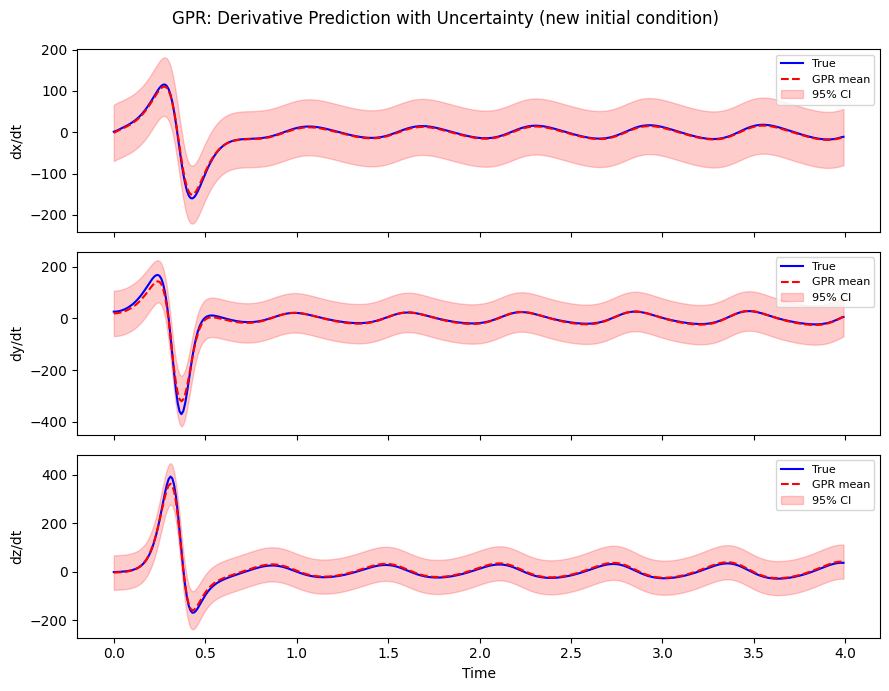

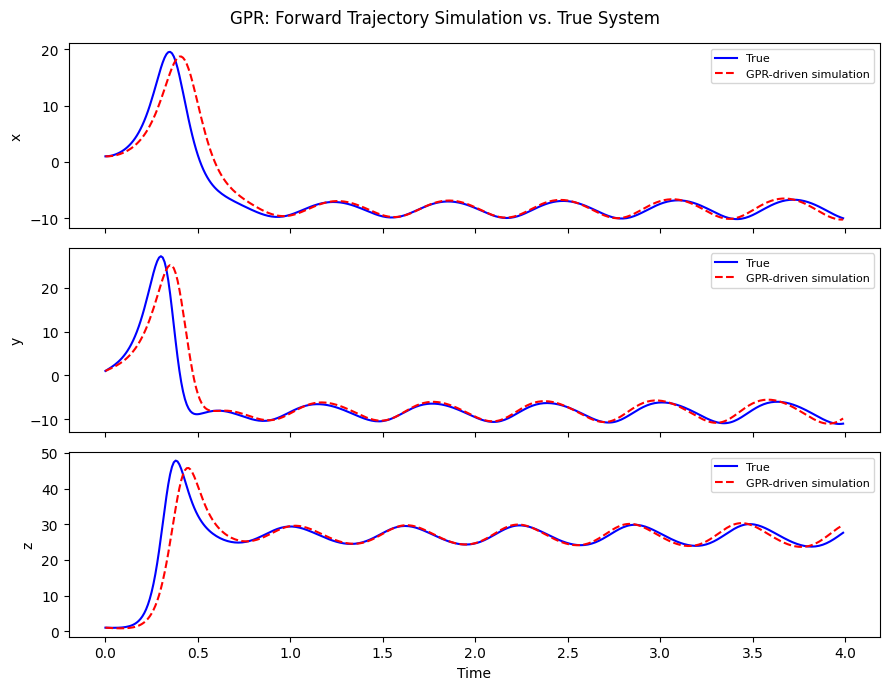


참고: 카오스 시스템(Lorenz)은 초기 오차가 지수적으로 커지므로 장시간 궤적 시뮬레이션은 SINDy처럼 잘 안 맞을 수 있음.
GPR의 강점은 '한 스텝 예측 + 불확실성 정량화'이지, 장기 궤적 재현이 아님 (제어 응용에서는 MPC의 예측 모델 등으로 활용).


In [7]:
#4. 실행
if __name__ == "__main__":
    np.random.seed(0)

    # 학습 데이터: 짧은 궤적 일부만 사용 (GPR은 데이터가 많으면 계산량이 커짐 - O(n^3))
    dt = 0.01
    t_train, X_train, dX_train = generate_data(dt=dt, t_end=4, noise_std=0.5)

    print(f"학습 샘플 수: {X_train.shape[0]}  (GPR은 O(n^3) 연산이라 샘플 수를 제한)")

    # GPR 학습
    models = train_gpr_models(X_train, dX_train)
    for k, gp in enumerate(models):
        print(f"  state {k+1} 학습된 커널: {gp.kernel_}")

    # 테스트: 학습에 사용하지 않은 새 초기조건에서 검증
    t_test = np.arange(0, 4, dt)
    _, X_test_true, dX_test_true = generate_data(dt=dt, t_end=4, x0=(1, 1, 1), noise_std=0.0)

    dX_pred_mean, dX_pred_std = predict_with_uncertainty(models, X_test_true)

    # 미분값 예측 정확도 + 불확실성 시각화
    fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
    labels = ["dx/dt", "dy/dt", "dz/dt"]
    for i, ax in enumerate(axes):
        ax.plot(t_test, dX_test_true[:, i], "b-", label="True", lw=1.5)
        ax.plot(t_test, dX_pred_mean[:, i], "r--", label="GPR mean", lw=1.5)
        ax.fill_between(
            t_test,
            dX_pred_mean[:, i] - 2 * dX_pred_std[:, i],
            dX_pred_mean[:, i] + 2 * dX_pred_std[:, i],
            color="r", alpha=0.2, label="95% CI"
        )
        ax.set_ylabel(labels[i])
        ax.legend(loc="upper right", fontsize=8)
    axes[-1].set_xlabel("Time")
    fig.suptitle("GPR: Derivative Prediction with Uncertainty (new initial condition)")
    plt.tight_layout()
    plt.show()

    # 순방향 궤적 시뮬레이션 비교 (GP 평균을 동역학으로 사용)
    X_gpr_traj = simulate_gpr_model(models, x0=(1, 1, 1), t_eval=t_test)

    fig2, axes2 = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
    state_labels = ["x", "y", "z"]
    for i, ax in enumerate(axes2):
        ax.plot(t_test, X_test_true[:, i], "b-", label="True", lw=1.5)
        ax.plot(t_test, X_gpr_traj[:, i], "r--", label="GPR-driven simulation", lw=1.5)
        ax.set_ylabel(state_labels[i])
        ax.legend(loc="upper right", fontsize=8)
    axes2[-1].set_xlabel("Time")
    fig2.suptitle("GPR: Forward Trajectory Simulation vs. True System")
    plt.tight_layout()
    plt.show()

    print(
        "\n참고: 카오스 시스템(Lorenz)은 초기 오차가 지수적으로 커지므로 "
        "장시간 궤적 시뮬레이션은 SINDy처럼 잘 안 맞을 수 있음.\n"
        "GPR의 강점은 '한 스텝 예측 + 불확실성 정량화'이지, "
        "장기 궤적 재현이 아님 (제어 응용에서는 MPC의 예측 모델 등으로 활용)."
    )